# Notebook 2: Preprocessing & Feature Selection

**Input:** `kidney_cells_clean.csv` or `kidney_cells_top_classes.csv` (from Notebook 1)  
**Output:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`

---

## What this notebook does
1. Load the cleaned dataset
2. Separate gene expression features and cell type labels
3. Take a stratified sample of 10,000 cells
4. Split into 80% training and 20% test sets
5. Feature reduction — all steps fit on training data only:
   - Remove zero-variance genes
   - Scale with StandardScaler
   - Remove near-zero-variance genes with VarianceThreshold
   - Use RFE to select the most informative genes
6. Save the four output files

---

**Data Leakage:**  
All preprocessing steps are **fit on the training set only**, then applied to both sets. Fitting on the full data before splitting would leak test set information into the model and produce unrealistically high evaluation scores.

## 1. Mount Google Drive

This connects the notebook to your Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

Set `data_dir` to your Google Drive folder.  
Set `INPUT_FILE` to choose between all 22 classes or the top 10 prominent classes only.

Import libraries and set up variables. Change `data_dir` to your Google Drive folder path. Change `input_file` if you want to work with only the top 10 classes instead of all 22.

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection   import train_test_split
from sklearn.preprocessing     import StandardScaler
from sklearn.feature_selection import VarianceThreshold, RFE
from sklearn.ensemble          import RandomForestClassifier
from sklearn.metrics           import f1_score

data_dir = Path('/content/drive/MyDrive/Colab Notebooks/Tisch ML Project')

# Options:
#   'kidney_cells_clean.csv'       — all 22 classes
#   'kidney_cells_top_classes.csv' — top 10 prominent classes only
input_file = 'kidney_cells_top_classes.csv'


clean_file    = data_dir / input_file
target_col    = 'Cell_Labels'
metadata_cols = ['Cell_ID', 'nCount_RNA', 'nFeature_RNA',
                 'StudyOrigin_Author', 'percent.mt',
                 'Sex', 'Sampling_Location', 'Age', 'Cell_Labels']

subset_size  = 10_000
test_size    = 0.2
random_seed  = 42
vt_threshold = 0.01

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries loaded.')

Libraries loaded.


## 3. Load Dataset

Load the cleaned dataset produced by Notebook 1 and print a quick summary.

In [3]:
print(f'Loading {input_file}...')
df = pd.read_csv(clean_file, low_memory=False)
print('Done.')
print()
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]:,}')
print(f'Classes : {df[target_col].nunique()}')

Loading kidney_cells_top_classes.csv...
Done.

Rows    : 50,218
Columns : 2,367
Classes : 10


## 4. Separate Features and Target

The features (X) are the 2,358 gene expression columns. The target (y) is the `Cell_Labels` column. All 9 metadata columns are excluded from X — cell type is determined by gene expression, not by patient age, sex, or study origin.

We separate the data into two parts: `X` contains the 2,358 gene expression columns (the inputs to the model), and `y` contains the cell type label for each cell (what we want the model to predict). The 9 metadata columns like age and sex are not included in `X` because cell type is determined by gene expression, not patient demographics.

In [4]:
# All columns that are NOT in the metadata list must be gene expression columns
gene_cols = [c for c in df.columns if c not in metadata_cols]

X = df[gene_cols].copy()
y = df[target_col].copy()

print(f'X shape : {X.shape}  ({X.shape[1]:,} gene columns)')
print(f'y shape : {y.shape}')
print(f'Classes : {y.nunique()}')
print()
print('Class distribution:')
for label, count in y.value_counts().items():
    print(f'  {label:<55}: {count:>6,}  ({count/len(y)*100:.1f}%)')

X shape : (50218, 2358)  (2,358 gene columns)
y shape : (50218,)
Classes : 10

Class distribution:
  Proximal Tubule                                        : 24,848  (49.5%)
  T                                                      :  3,436  (6.8%)
  Ascending Thin Limb                                    :  3,105  (6.2%)
  Thick Ascending Limb                                   :  2,735  (5.4%)
  Myeloid                                                :  2,605  (5.2%)
  Endothelium                                            :  2,378  (4.7%)
  Loop of Henle and Parietal Epithelium                  :  1,843  (3.7%)
  Distal Convoluted Tubule                               :  1,814  (3.6%)


## 5. Stratified Sample of 10,000 Cells

The full dataset has ~60,000 cells. Running RFE on all of them would take many hours. We take a stratified sample of 10,000 cells, which preserves class proportions — if Proximal Tubule makes up 37% of the full dataset it will also make up approximately 37% of the sample.

Two methods are shown. Run only one.

Method A: we define a function that calculates how many cells to take from each class proportionally, then apply it to every class using `groupby`. For example, if Proximal Tubule makes up 37% of the full dataset, we take 3,700 cells of that type for our 10,000-cell sample.

In [7]:
# Method A — proportional sampling per class
# For each class: n = subset_size x (class_size / total_size)
# e.g. total=60000, subset=10000, Proximal Tubule=24000 → n = 10000 x (24000/60000) = 4000

full_df = X.copy()
full_df[target_col] = y.values

def sample_group(group):
    n = max(1, int(subset_size * len(group) / len(full_df)))
    return group.sample(n=n, random_state=random_seed)

# Split by cell type, sample each group proportionally, then stack back together
subset_df = full_df.groupby(target_col, group_keys=False).apply(sample_group, include_groups=False)

# Since include_groups=False removes the target_col, we can get y_sub from the original y using the index
X_sub = subset_df.copy()
y_sub = y.loc[X_sub.index].copy()

print(f'Method A — subset size : {len(X_sub):,} cells')
print(f'           classes     : {y_sub.nunique()}')

Method A — subset size : 9,995 cells
           classes     : 10


**Why is the subset slightly less than 10,000?**

When we calculate the exact proportional share for each cell type, the math usually gives us a decimal (for example, we might need exactly 850.7 cells of a certain type). Because we can't have a fraction of a cell, the code rounds down to the nearest whole number (taking 850 cells). Since we round down for every single group, those missing fractions add up, leaving our final total just a tiny bit short of exactly 10,000.

Method B is an alternative way to do the same thing using `train_test_split`. It is commented out — uncomment it and comment out Method A if you prefer this approach.

In [ ]:
# Method B — using train_test_split
# Uncomment this block and comment out Method A to use instead.

# _, X_sub, _, y_sub = train_test_split(
#     X, y,
#     test_size=subset_size,
#     random_state=random_seed,
#     stratify=y
# )
# print(f'Method B — subset size : {len(X_sub):,} cells')
# print(f'           classes     : {y_sub.nunique()}')

print('Method B is commented out. Using Method A.')

We print the class proportions in the full dataset and in the sample side by side to confirm they match. If the numbers look similar, the stratified sampling worked correctly.

In [8]:
# Double-check that the class proportions in the sample match the full dataset
# Verify class proportions are preserved
full_pct   = y.value_counts(normalize=True).sort_index() * 100
subset_pct = y_sub.value_counts(normalize=True).sort_index() * 100
print('Class proportions — full vs subset:')
print(pd.DataFrame({'Full (%)': full_pct, 'Subset (%)': subset_pct}).round(1).to_string())

Class proportions — full vs subset:
                                       Full (%)  Subset (%)
Cell_Labels                                                
Ascending Thin Limb                         6.2         6.2
Distal Convoluted Tubule                    3.6         3.6
Endothelium                                 4.7         4.7
Loop of Henle and Parietal Epithelium       3.7         3.7
Myeloid                                     5.2         5.2
Proximal Tubule                            49.5        49.5
T                                           6.8         6.8
Thick Ascending Limb                        5.4         5.4


## 6. Train / Test Split

80% of the subset goes to training, 20% to testing. `stratify=y_sub` keeps class proportions equal in both sets. `random_state=42` makes the split reproducible.

We split the 10,000-cell sample into a training set (8,000 cells) and a test set (2,000 cells). The `stratify` argument ensures each set has the same proportion of each cell type. We then print a verification table to confirm this.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub,
    test_size=test_size,
    random_state=random_seed,
    stratify=y_sub
)

print(f'Training set : {X_train.shape[0]:,} cells')
print(f'Test set     : {X_test.shape[0]:,} cells')
print(f'Features     : {X_train.shape[1]:,} gene columns')
print()

train_pct   = y_train.value_counts(normalize=True).sort_index() * 100
test_pct    = y_test.value_counts(normalize=True).sort_index() * 100
split_check = pd.DataFrame({'Train (%)': train_pct, 'Test (%)': test_pct}).round(1)
print('Stratification check:')
print(split_check.to_string())

Training set : 7,996 cells
Test set     : 1,999 cells
Features     : 2,358 gene columns

Stratification check:
                                       Train (%)  Test (%)
Cell_Labels                                               
Ascending Thin Limb                          6.2       6.2
Distal Convoluted Tubule                     3.6       3.6
Endothelium                                  4.7       4.8
Loop of Henle and Parietal Epithelium        3.7       3.7
Myeloid                                      5.2       5.2
Proximal Tubule                             49.5      49.5
T                                            6.8       6.9
Thick Ascending Limb                         5.4       5.5


## 7. Feature Reduction

We have 2,358 gene expression features. Many will be uninformative. We reduce them in five steps, all fitted on training data only.

| Step | Method | Purpose |
|---|---|---|
| 1 | Zero-variance removal | Remove genes that are exactly 0 in every training cell |
| 2 | High-null removal | Remove genes where more than 90% of values are missing |
| 3 | StandardScaler | Normalise expression values to mean=0, std=1 |
| 4 | VarianceThreshold | Remove genes with near-zero variance after scaling |
| 5 | RFE | Rank and select the most predictive genes |

**Note on RFE estimator:** RFE needs a model with feature importance scores to rank genes. KNN (used in Notebook 3) and SVM with an RBF kernel (Notebook 4) do not produce these scores, so they cannot be placed inside RFE directly. We use a lightweight Random Forest inside RFE solely as a feature ranker — it is fast and produces reliable importance scores. The selected features are then passed to KNN and SVM for classification. This is standard practice.

### Step 1 — Remove Zero-Variance Genes

A gene with zero variance has the exact same value in every training cell. It carries no information — the model cannot learn anything from a feature that never changes.

We calculate the variance of each gene across all training cells. Any gene that has exactly zero variance — meaning every single training cell has the same value for that gene — is dropped. A feature that never changes cannot help the model distinguish cell types.

In [10]:
train_variance = X_train.var()
zero_var_cols  = train_variance[train_variance == 0].index.tolist()

print(f'Genes with zero variance : {len(zero_var_cols):,}')

if len(zero_var_cols) > 0:
    X_train = X_train.drop(columns=zero_var_cols)
    X_test  = X_test.drop(columns=zero_var_cols)
    print(f'Removed. Genes remaining : {X_train.shape[1]:,}')
else:
    print(f'None removed. Genes remaining : {X_train.shape[1]:,}')

Genes with zero variance : 69
Removed. Genes remaining : 2,289


### Step 2 — Remove High-Null Genes

Any gene column where more than 90% of values are missing (NaN) is removed. A column with that many missing values is too sparse to be useful — you cannot reliably impute or learn from a feature that is absent in almost all cells.

In this dataset the gene expression columns store undetected genes as 0 rather than NaN, so we expect no columns to be removed here. The step is included because it is the correct thing to check, and because it mirrors the same step in the Sepsis preprocessing pipeline.

We check each gene column for missing values. Any gene where more than 90% of training cells have no value is removed. In this dataset we expect to find none, because undetected genes are stored as 0 rather than as missing, but the check is the right thing to do.

In [11]:
null_threshold = 0.90

# Calculate null % per gene column on the training set only
null_pct      = X_train.isnull().mean()
high_null_cols = null_pct[null_pct > null_threshold].index.tolist()

print(f'Null threshold : {null_threshold * 100:.0f}%')
print(f'Genes with >{null_threshold * 100:.0f}% null values : {len(high_null_cols):,}')

if len(high_null_cols) > 0:
    X_train = X_train.drop(columns=high_null_cols)
    X_test  = X_test.drop(columns=high_null_cols)
    print(f'Removed. Genes remaining : {X_train.shape[1]:,}')
else:
    print('None removed. Gene expression columns contain no null values.')
    print(f'Genes remaining : {X_train.shape[1]:,}')

Null threshold : 90%
Genes with >90% null values : 0
None removed. Gene expression columns contain no null values.
Genes remaining : 2,289


### Step 3 — StandardScaler

StandardScaler rescales each gene's values to have a mean of 0 and standard deviation of 1 across all training cells. This ensures that genes with naturally larger count values do not dominate the variance calculation in the next step.

Fitted on training set only (`fit_transform`), then applied to the test set (`transform`).

StandardScaler rescales every gene so it has a mean of 0 and a standard deviation of 1 across the training cells. This puts all genes on the same scale so that genes with naturally large count values do not dominate the variance calculation in the next step. Crucially, the scaler is fitted only on the training set and then applied to both sets.

In [12]:
current_cols = X_train.columns.tolist()

scaler     = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=current_cols, index=X_train.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=current_cols, index=X_test.index)

print('StandardScaler applied.')
print(f'Mean of first gene (train) : {X_train_sc.iloc[:, 0].mean():.4f}  (should be ~0)')
print(f'Std  of first gene (train) : {X_train_sc.iloc[:, 0].std():.4f}  (should be ~1)')

StandardScaler applied.
Mean of first gene (train) : 0.0000  (should be ~0)
Std  of first gene (train) : 1.0001  (should be ~1)


### Step 4 — VarianceThreshold

After scaling, genes that are near-zero in most cells will still have very low variance. `VarianceThreshold` removes any gene whose variance across all training cells falls below the threshold of 0.01.

`vt.get_support()` returns a boolean array — `True` for genes that pass, `False` for genes removed. This same mask is applied to both training and test sets.

VarianceThreshold removes genes whose variance (after scaling) is below 0.01. These are genes that barely change from cell to cell and therefore carry very little information. `get_support()` returns a True/False list — True means keep the gene, False means remove it — and we use that same list on both the training and test sets.

In [13]:
vt = VarianceThreshold(threshold=vt_threshold)
vt.fit(X_train_sc)

# vt.get_support() → [True, False, True, True, False, ...]  (True = keep)
vt_support   = vt.get_support()
kept_cols    = X_train_sc.columns[vt_support].tolist()
removed_cols = X_train_sc.columns[~vt_support].tolist()

X_train_vt = X_train_sc[kept_cols]
X_test_vt  = X_test_sc[kept_cols]

print(f'VarianceThreshold (threshold = {vt_threshold})')
print(f'Before : {X_train_sc.shape[1]:,} genes')
print(f'Removed: {len(removed_cols):,} genes')
print(f'After  : {len(kept_cols):,} genes')

VarianceThreshold (threshold = 0.01)
Before : 2,289 genes
Removed: 0 genes
After  : 2,289 genes


### Step 5 — RFE: Finding the Optimal Number of Features

Recursive Feature Elimination (RFE) works by:
1. Training a model on the current feature set
2. Ranking each feature by its importance
3. Removing the least important feature
4. Repeating until `k` features remain

To find the best `k`, we run a sweep across several candidate values. For each `k`, we train a small evaluation model and record the weighted F1 score. We then pick the `k` with the highest score.

The candidate values are generated by starting at N // 4 and halving each time.

We want to find the best number of genes to keep. We test a range of values of k (starting at one quarter of the remaining genes and halving each time). For each k, RFE selects the top k genes using a small Random Forest as a ranker, then a slightly larger model evaluates how well those k genes predict cell type. The results are printed as each k finishes.

In [15]:
n = X_train_vt.shape[1]

# Build the list of k values to test — start at 25% of features, halve each time
feature_counts = []
k = n // 4
while k >= 1:
    feature_counts.append(k)
    k = k // 2

print(f'Features after VT   : {n:,}')
print(f'Candidate k values  : {feature_counts}')
print()
print('Starting RFE')

# Lightweight RF used inside RFE only for feature ranking
rfe_estimator = RandomForestClassifier(n_estimators=10, max_depth=4, random_state=random_seed, n_jobs=-1)

# Slightly larger RF to evaluate each k
eval_model = RandomForestClassifier(n_estimators=30, max_depth=5, random_state=random_seed, n_jobs=-1)

f1_scores = []

for k in feature_counts:
    rfe = RFE(estimator=rfe_estimator, n_features_to_select=k)
    rfe.fit(X_train_vt, y_train)

    X_tr_k = X_train_vt.loc[:, rfe.support_]
    X_te_k = X_test_vt.loc[:, rfe.support_]

    eval_model.fit(X_tr_k, y_train)
    f1 = f1_score(y_test, eval_model.predict(X_te_k), average='weighted')
    f1_scores.append(f1)

    print(f'  k = {k:>5,}  →  Weighted F1 = {f1:.4f}')

best_idx = int(np.argmax(f1_scores))
best_k   = feature_counts[best_idx]
best_f1  = f1_scores[best_idx]
print()
print(f'Best k : {best_k:,}  (Weighted F1 = {best_f1:.4f})')

Features after VT   : 2,289
Candidate k values  : [572, 286, 143, 71, 35, 17, 8, 4, 2, 1]

Starting RFE
  k =   572  →  Weighted F1 = 0.3703
  k =   286  →  Weighted F1 = 0.3987
  k =   143  →  Weighted F1 = 0.4052
  k =    71  →  Weighted F1 = 0.4085
  k =    35  →  Weighted F1 = 0.4220
  k =    17  →  Weighted F1 = 0.4740
  k =     8  →  Weighted F1 = 0.4658
  k =     4  →  Weighted F1 = 0.4404
  k =     2  →  Weighted F1 = 0.3532
  k =     1  →  Weighted F1 = 0.3288

Best k : 17  (Weighted F1 = 0.4740)


This plots the weighted F1 score for each value of k we tested. The red dashed line marks the best k — the point where the model performed best on the test set. If two k values give similar scores, you can choose the smaller one to keep the model simpler.

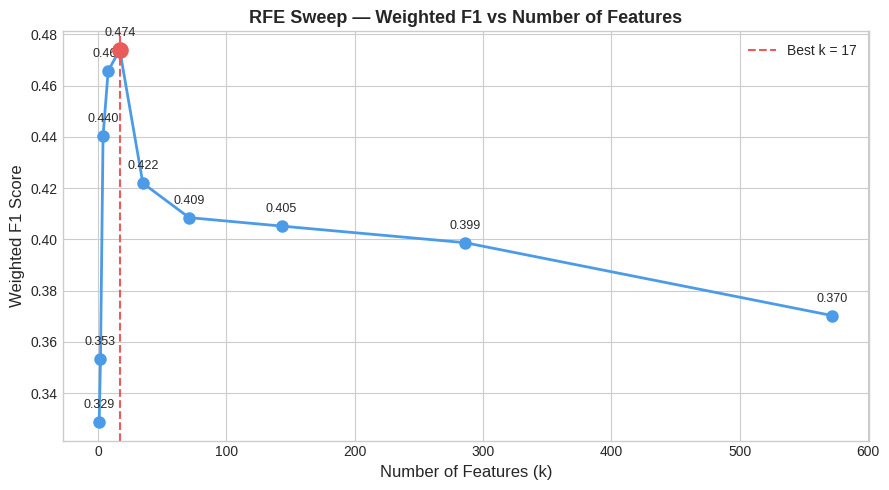

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(feature_counts, f1_scores, marker='o', color='#4C9BE8', linewidth=2, markersize=8)
for k_val, f1_val in zip(feature_counts, f1_scores):
    ax.annotate(f'{f1_val:.3f}', (k_val, f1_val),
                textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)

ax.axvline(x=best_k, color='#E85C5C', linestyle='--', linewidth=1.5, label=f'Best k = {best_k:,}')
ax.scatter([best_k], [best_f1], color='#E85C5C', s=120, zorder=5)

ax.set_title('RFE Sweep — Weighted F1 vs Number of Features', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Features (k)', fontsize=12)
ax.set_ylabel('Weighted F1 Score', fontsize=12)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

### Final RFE

Run RFE one final time with the best k to get the definitive list of selected genes. Override `n_features_selected` below if you prefer a different value.

We run RFE one final time using the best k to get the definitive list of selected genes. These are the genes that will be used to train the KNN and SVM models in Notebooks 3 and 4.

In [17]:
n_features_selected = best_k   # <-- override here if needed

print(f'Running final RFE with k = {n_features_selected:,}...')

final_rfe = RFE(
    estimator=RandomForestClassifier(n_estimators=10, max_depth=4, random_state=random_seed, n_jobs=-1),
    n_features_to_select=n_features_selected
)
final_rfe.fit(X_train_vt, y_train)

# Pull out the names of the winning genes
selected_features = X_train_vt.columns[final_rfe.support_].tolist()

# Filter both sets down to just the selected genes
X_train_final = X_train_vt[selected_features]
X_test_final  = X_test_vt[selected_features]

print('Done.')
print()
print(f'Selected genes ({len(selected_features):,}):')
for gene in selected_features:
    print(f'  {gene}')

Running final RFE with k = 17...
Done.

Selected genes (17):
  ACVRL1
  AFP
  APOBEC3G
  ATP2B1
  ATP5A1
  ATP5G3
  AVPR2
  AZGP1
  BRD2
  BTBD7
  BTG3
  CA2
  CD96
  CRYAB
  CXCL14
  CYBA
  LINC02421


## 8. Save Output Files

We save the four output files to Google Drive. These are what Notebooks 3 and 4 will load. `X_train` and `X_test` contain the gene expression values for the selected genes. `y_train` and `y_test` contain the corresponding cell type labels.

In [18]:
X_train_final.to_csv(data_dir / 'X_train.csv', index=True)
X_test_final.to_csv(data_dir / 'X_test.csv',   index=True)
y_train.to_csv(data_dir / 'y_train.csv',        index=True, header=True)
y_test.to_csv(data_dir / 'y_test.csv',          index=True, header=True)

print('Saved:')
print(f'  X_train.csv : {X_train_final.shape[0]:,} x {X_train_final.shape[1]:,}')
print(f'  X_test.csv  : {X_test_final.shape[0]:,} x {X_test_final.shape[1]:,}')
print(f'  y_train.csv : {len(y_train):,} labels')
print(f'  y_test.csv  : {len(y_test):,} labels')

Saved:
  X_train.csv : 7,996 x 17
  X_test.csv  : 1,999 x 17
  y_train.csv : 7,996 labels
  y_test.csv  : 1,999 labels


## 9. Summary

A printout showing how many genes were removed at each step and the final shape of the training and test sets.

In [ ]:
print('=' * 60)
print('NOTEBOOK 2 — FEATURE REDUCTION SUMMARY')
print('=' * 60)
print()
print(f'Original gene features         : {len(gene_cols):,}')
print(f'After zero-variance removal    : {X_train.shape[1]:,}')
print(f'After high-null removal (>90%) : {X_train.shape[1]:,}')
print(f'After VarianceThreshold (0.01) : {len(kept_cols):,}')
print(f'After RFE (k = {n_features_selected:,})          : {len(selected_features):,}')
print()
print(f'Reduction : {len(gene_cols):,} → {len(selected_features):,} features  ({len(selected_features)/len(gene_cols)*100:.1f}% kept)')
print()
print(f'Training set : {X_train_final.shape[0]:,} cells x {X_train_final.shape[1]:,} genes')
print(f'Test set     : {X_test_final.shape[0]:,} cells x {X_test_final.shape[1]:,} genes')
print(f'Classes      : {y_train.nunique()}')
print()
print('=' * 60)
print('Next: run 03_knn.ipynb')
print('=' * 60)